# CMJM Lab Entry Assessment — Starter Notebook

- **Student:** 黃安華 
- **ID:** r15h45007
- **Date:** 2026-09-05
- **Task description reference:**  Task v1.0, received 2026-09-05

---

## AI Assistance Disclosure
Used Antigravity (Claude Sonnet 4.6, Gemini 3.8 Flash) to help write and debug Python scripts for data inspection and solution.py. All code was reviewed and understood by the author.

---

## 0. Environment & Imports

In [1]:
# Standard scientific stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Optional — uncomment if needed
# from scipy import stats
# from sklearn.metrics import mean_squared_error, r2_score
# import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# Plotting defaults
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (8, 5)})
sns.set_theme(style='whitegrid')

# Print versions for reproducibility documentation
print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')
print(f'Python  : ', end='')
import sys; print(sys.version.split()[0])

pandas  : 3.0.5
numpy   : 1.26.4
Python  : 3.11.16


## 1. Data Loading

> **CMJM criterion:** "Understanding its structure *before* manipulating it."

Load every file you receive. Inspect before touching.

In [3]:
DATA_DIR = Path("data")

train    = pd.read_csv(DATA_DIR / "train.csv")
test     = pd.read_csv(DATA_DIR / "test.csv")
cell_emb = pd.read_csv(DATA_DIR / "global_cell_embeddings.csv")
drug_emb = pd.read_csv(DATA_DIR / "drug_embeddings.csv")

for name, df in [("train", train), ("test", test),
                 ("cell_emb", cell_emb), ("drug_emb", drug_emb)]:
    print(f"{name:10s} → {df.shape[0]} rows × {df.shape[1]} cols")
    print(f"  columns: {list(df.columns)}\n")


train      → 503 rows × 4 cols
  columns: ['sample_id', 'cell_line_id', 'drug_id', 'response']

test       → 100 rows × 3 cols
  columns: ['sample_id', 'cell_line_id', 'drug_id']

cell_emb   → 360 rows × 33 cols
  columns: ['cell_line_id', 'emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9', 'emb_10', 'emb_11', 'emb_12', 'emb_13', 'emb_14', 'emb_15', 'emb_16', 'emb_17', 'emb_18', 'emb_19', 'emb_20', 'emb_21', 'emb_22', 'emb_23', 'emb_24', 'emb_25', 'emb_26', 'emb_27', 'emb_28', 'emb_29', 'emb_30', 'emb_31']

drug_emb   → 208 rows × 33 cols
  columns: ['drug_id', 'emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9', 'emb_10', 'emb_11', 'emb_12', 'emb_13', 'emb_14', 'emb_15', 'emb_16', 'emb_17', 'emb_18', 'emb_19', 'emb_20', 'emb_21', 'emb_22', 'emb_23', 'emb_24', 'emb_25', 'emb_26', 'emb_27', 'emb_28', 'emb_29', 'emb_30', 'emb_31']



## 2. Data Inspection (Before Any Processing)

> **CMJM criterion:** Checking for errors, inconsistencies, gaps — *show the evidence*.

In [ ]:
def inspect_dataframe(df, name='df'):
    """Quick inspection report for any DataFrame — run on every file you load."""
    print(f'=== {name} ===' )
    print(f'Shape       : {df.shape[0]:,} rows × {df.shape[1]} columns')
    print(f'Duplicates  : {df.duplicated().sum():,} full-row duplicates')
    print()

    # Missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(1)
    missing_report = pd.DataFrame({'missing_n': missing, 'missing_%': missing_pct})
    missing_report = missing_report[missing_report['missing_n'] > 0]
    if len(missing_report) == 0:
        print('Missing values: none')
    else:
        print('Missing values:')
        print(missing_report)
    print()

    # Basic stats for numeric columns
    print('Numeric summary:')
    display(df.describe())

    return missing_report


# Uncomment and use:
# missing = inspect_dataframe(df, name='my_data')

In [ ]:
def check_join_key(df_left, df_right, key, name_left='left', name_right='right'):
    """
    Before merging two tables on a shared key:
    - Shows how many records will match, be left-only, or right-only.
    - CMJM criterion: 'understand what happens to records that fail to match'
    """
    left_keys  = set(df_left[key].dropna())
    right_keys = set(df_right[key].dropna())

    both   = left_keys & right_keys
    l_only = left_keys - right_keys
    r_only = right_keys - left_keys

    print(f'Join key      : "{key}"')
    print(f'Matched       : {len(both):,}  keys in both tables')
    print(f'{name_left:13s} only : {len(l_only):,}  keys (will become NaN after right/inner join)')
    print(f'{name_right:13s} only : {len(r_only):,}  keys (will become NaN after left/inner join)')

    if l_only:
        print(f'\n{name_left}-only sample:', list(l_only)[:5])
    if r_only:
        print(f'\n{name_right}-only sample:', list(r_only)[:5])


# Uncomment and use:
# check_join_key(df_a, df_b, key='sample_id', name_left='clinical', name_right='genomics')
# df_merged = pd.merge(df_a, df_b, on='sample_id', how='inner')  # or 'left', 'outer'

In [7]:
# 用 inspect_dataframe 檢查每個檔案
inspect_dataframe(train,    name="train")
inspect_dataframe(test,     name="test")
inspect_dataframe(cell_emb, name="cell_emb")
inspect_dataframe(drug_emb, name="drug_emb")


=== train ===
Shape       : 503 rows × 4 columns
Duplicates  : 0 full-row duplicates

Missing values: none

Numeric summary:


,response
count,503.000000
mean,2.642910
std,3.112900
min,-7.140523
25%,1.137595
50%,3.100867
75%,4.664434
max,10.822420


=== test ===
Shape       : 100 rows × 3 columns
Duplicates  : 0 full-row duplicates

Missing values: none

Numeric summary:


,sample_id,cell_line_id,drug_id
count,100,100,100
unique,100,91,86
top,TEST_0001,RPMI7951,Talazoparib
freq,1,2,3


=== cell_emb ===
Shape       : 360 rows × 33 columns
Duplicates  : 0 full-row duplicates

Missing values:
        missing_n  missing_%
emb_6           1        0.3
emb_30          1        0.3
emb_31          1        0.3

Numeric summary:


,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_22,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,359.000000,360.000000,360.000000,360.000000,...,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,359.000000,359.000000
mean,0.392883,-0.154382,0.488634,1.270624,-0.171535,-0.159377,1.292569,0.617348,-0.377897,0.432535,...,0.040282,-1.171088,-0.463683,0.080542,-0.976370,0.289850,-0.496151,-0.240250,-0.526737,1.542183
std,0.525845,0.501908,0.487007,0.626891,0.493728,0.531137,0.644842,0.518822,0.516168,0.538328,...,0.523102,0.630536,0.558037,0.468224,0.590192,0.510624,0.506094,0.482615,0.527289,0.720066
min,-0.828361,-1.679118,-0.915550,-0.563957,-1.814557,-1.590673,-0.691819,-0.858156,-2.044370,-1.206005,...,-1.313300,-2.986662,-2.501963,-1.271174,-2.788794,-1.271539,-1.962397,-2.055164,-2.136627,-0.095473
25%,0.049923,-0.492287,0.195681,0.897039,-0.477132,-0.519189,0.917575,0.245272,-0.688771,0.105870,...,-0.299008,-1.581222,-0.829483,-0.227259,-1.391978,-0.048521,-0.870287,-0.581598,-0.890002,1.000866
50%,0.395204,-0.160911,0.458188,1.282669,-0.163835,-0.197152,1.272096,0.652626,-0.354490,0.436207,...,0.020851,-1.196887,-0.489703,0.071275,-0.986298,0.296774,-0.498722,-0.244685,-0.515936,1.544576
75%,0.726990,0.217039,0.804244,1.681330,0.139041,0.193506,1.724827,0.959634,-0.030053,0.798894,...,0.382491,-0.802763,-0.053742,0.374785,-0.586991,0.641672,-0.154850,0.085086,-0.163227,2.019063
max,1.919976,1.479023,2.047615,2.966814,1.426998,1.381331,3.069923,2.063873,1.163064,2.037869,...,1.662585,0.923025,1.493340,1.534735,0.755495,1.610233,0.775568,0.986363,1.359358,3.924535


=== drug_emb ===
Shape       : 208 rows × 33 columns
Duplicates  : 0 full-row duplicates

Missing values: none

Numeric summary:


,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_22,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,-0.022255,-0.851159,0.681473,-0.999946,0.185277,-1.559464,-1.092179,0.142423,0.620348,0.185945,...,0.837087,0.768893,-0.684358,-0.213371,0.243452,0.814761,-0.342545,-0.175507,-0.931649,-0.996887
std,0.531884,0.976689,0.791805,0.999584,0.534473,1.485298,1.087509,0.492377,0.716274,0.499590,...,0.873100,0.799571,0.780888,0.548251,0.539502,0.915992,0.650524,0.502386,0.966519,0.989578
min,-1.445213,-3.362468,-1.805573,-3.459791,-1.312009,-6.139954,-4.286325,-1.247354,-1.578421,-1.421196,...,-2.185357,-1.849437,-2.445664,-1.666732,-1.633162,-2.233087,-2.279925,-1.572107,-3.705366,-3.371789
25%,-0.358748,-1.514254,0.246080,-1.691466,-0.151278,-2.488682,-1.827507,-0.148739,0.170541,-0.109823,...,0.427345,0.289229,-1.236348,-0.587295,-0.105833,0.293369,-0.767355,-0.547343,-1.562441,-1.656427
50%,-0.017042,-0.951750,0.762441,-1.083286,0.205051,-1.798129,-1.162841,0.156075,0.628302,0.186343,...,0.946711,0.891157,-0.808244,-0.198036,0.250140,0.904418,-0.383823,-0.158809,-1.056974,-1.139014
75%,0.363205,-0.257372,1.228070,-0.419846,0.548361,-0.991870,-0.558132,0.472251,1.113185,0.462363,...,1.426341,1.322168,-0.224811,0.223539,0.586823,1.339852,0.109004,0.178709,-0.408549,-0.394701
max,1.578262,2.364545,2.406214,2.229651,1.824069,3.442951,2.391981,1.652625,2.309245,1.642187,...,3.391468,2.529324,2.018479,0.962902,1.968928,3.319119,1.459735,1.063353,2.108173,2.481408


,missing_n,missing_%


In [8]:
# strip trailing space 先做（已知問題）
train["drug_id"] = train["drug_id"].str.strip()
test["drug_id"]  = test["drug_id"].str.strip()

# 確認 train 的 ID 在 embedding 表裡都找得到
check_join_key(train, cell_emb, key="cell_line_id", name_left="train", name_right="cell_emb")
print()
check_join_key(train, drug_emb, key="drug_id",      name_left="train", name_right="drug_emb")
print()
check_join_key(test,  cell_emb, key="cell_line_id", name_left="test",  name_right="cell_emb")


Join key      : "cell_line_id"
Matched       : 328  keys in both tables
train         only : 0  keys (will become NaN after right/inner join)
cell_emb      only : 32  keys (will become NaN after left/inner join)

cell_emb-only sample: ['SIGM5', 'MOLM16', 'HUH1', 'SIMA', 'CAL148']

Join key      : "drug_id"
Matched       : 197  keys in both tables
train         only : 0  keys (will become NaN after right/inner join)
drug_emb      only : 11  keys (will become NaN after left/inner join)

drug_emb-only sample: ['Cisplatin', 'LY2109761', 'Mirin', 'GSK2578215A', 'AZD8186']

Join key      : "cell_line_id"
Matched       : 89  keys in both tables
test          only : 2  keys (will become NaN after right/inner join)
cell_emb      only : 271  keys (will become NaN after left/inner join)

test-only sample: ['ABC1', 'A427']

cell_emb-only sample: ['NCIH1781', 'JHH6', 'HEP3B217', 'HL60', 'KE37']


## 3. Data Cleaning & Decisions

> **CMJM criterion:** "Make a reasoned decision about how to handle it, and say why."

For every cleaning step, write *why* in a markdown cell below it.

In [9]:
# ── 1. 重複行（cell_line_id + drug_id + response 相同，sample_id 不同）──
dups = train.duplicated(subset=["cell_line_id", "drug_id", "response"], keep=False)
print(f"重複的行（全部標示）: {dups.sum()} 筆")
print(train[dups].sort_values(["cell_line_id", "drug_id"]))

# DECISION: 保留第一筆，刪除後續重複
# REASON: 同一個 cell+drug 只需要一個 response 值；sample_id 只是編號，沒有實質意義
# RISK: 如果同一對 cell+drug 有兩個不同 response，這裡會錯殺 → 但 subset 包含 response，所以 response 必須相同才會被視為重複
train_clean = train.drop_duplicates(subset=["cell_line_id", "drug_id", "response"], keep="first")
print(f"\ntrain 清理後: {len(train)} → {len(train_clean)} 筆")


重複的行（全部標示）: 6 筆
      sample_id cell_line_id     drug_id  response
201  TRAIN_0202         A172   Nilotinib  3.761720
500  TRAIN_0501         A172   Nilotinib  3.761720
304  TRAIN_0305        MESSA  Dabrafenib  5.251605
501  TRAIN_0502        MESSA  Dabrafenib  5.251605
94   TRAIN_0095        ST486       SN-38 -4.422722
502  TRAIN_0503        ST486       SN-38 -4.422722

train 清理後: 503 → 500 筆


In [10]:
# ── 2. cell embedding NaN → 用該維度的平均值填補 ──
emb_cols = [c for c in cell_emb.columns if c.startswith("emb_")]

print("填補前 NaN 數量:")
print(cell_emb[emb_cols].isna().sum()[cell_emb[emb_cols].isna().sum() > 0])

# DECISION: 用各維度的 column mean 填補
# REASON: 只有 3 個 NaN，比例極低(0.3%)；mean imputation 是最簡單且不會引入偏差的方法
# RISK: 若該 cell line 的值本來就很特殊，mean 會低估其異常程度
cell_emb_clean = cell_emb.copy()
for col in emb_cols:
    col_mean = cell_emb_clean[col].mean()
    cell_emb_clean[col] = cell_emb_clean[col].fillna(col_mean)

print("\n填補後 NaN 數量:", cell_emb_clean[emb_cols].isna().sum().sum())


填補前 NaN 數量:
emb_6     1
emb_30    1
emb_31    1
dtype: int64

填補後 NaN 數量: 0


In [11]:
# ── 3. test 中找不到 embedding 的 cell_line_id ──
test_no_emb = set(test["cell_line_id"]) - set(cell_emb_clean["cell_line_id"])
print(f"test 中沒有 embedding 的 cell_line_id: {test_no_emb}")
affected_rows = test[test["cell_line_id"].isin(test_no_emb)]
print(f"影響的 test 行數: {len(affected_rows)}")
print(affected_rows)

# DECISION: 將這些行從 test_processed 中移除
# REASON: 沒有 cell embedding 就無法建構 feature vector，不能餵給模型
# RISK: 若這些 sample 是評分的一部分，會漏掉預測
test_clean = test[~test["cell_line_id"].isin(test_no_emb)].copy()
print(f"\ntest 清理後: {len(test)} → {len(test_clean)} 筆")


test 中沒有 embedding 的 cell_line_id: {'ABC1', 'A427'}
影響的 test 行數: 2
    sample_id cell_line_id      drug_id
6   TEST_0007         ABC1       AZ6102
39  TEST_0040         A427  GSK2578215A

test 清理後: 100 → 98 筆


In [12]:
# ── Part 2: Merge 成 processed feature table ──────────────────────────────

# 欄位重新命名，避免 cell 和 drug 的 emb_0~31 撞名
cell_emb_renamed = cell_emb_clean.rename(
    columns={c: f"cell_{c}" for c in emb_cols}
)
drug_emb_renamed = drug_emb.rename(
    columns={c: f"drug_{c}" for c in [col for col in drug_emb.columns if col.startswith("emb_")]}
)

# train_processed: train_clean + cell embedding + drug embedding
train_processed = (
    train_clean
    .merge(cell_emb_renamed, on="cell_line_id", how="left")
    .merge(drug_emb_renamed, on="drug_id",      how="left")
)

# test_processed: test_clean + cell embedding + drug embedding
test_processed = (
    test_clean
    .merge(cell_emb_renamed, on="cell_line_id", how="left")
    .merge(drug_emb_renamed, on="drug_id",      how="left")
)

# 確認維度
print(f"train_processed: {train_processed.shape}")  # 期望: 500 × (4 + 32 + 32) = 500 × 68
print(f"test_processed:  {test_processed.shape}")   # 期望: 98 × (3 + 32 + 32) = 98 × 67

# 確認沒有 NaN（merge 成功的話不應該有）
print(f"\ntrain_processed NaN: {train_processed.isna().sum().sum()}")
print(f"test_processed  NaN: {test_processed.isna().sum().sum()}")

# 存檔
train_processed.to_csv("train_processed.csv", index=False)
test_processed.to_csv("test_processed.csv",   index=False)
print("\n✅ 已存 train_processed.csv 和 test_processed.csv")


train_processed: (500, 68)
test_processed:  (98, 67)

train_processed NaN: 0
test_processed  NaN: 0

✅ 已存 train_processed.csv 和 test_processed.csv


In [ ]:
from pathlib import Path
Path("figures").mkdir(exist_ok=True)

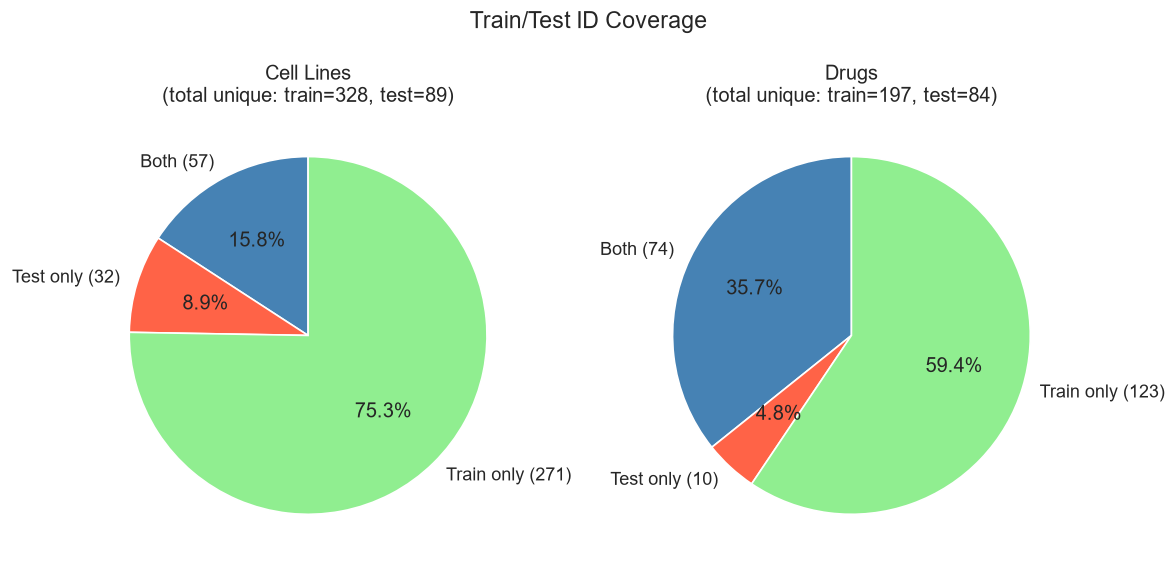

[saved] figures/fig_id_overlap_pie.png


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Train/Test ID Coverage", fontsize=14)

# cell line 的 overlap 分析
train_cells = set(train_proc["cell_line_id"])
test_cells  = set(test_processed["cell_line_id"])
cell_both     = len(train_cells & test_cells)
cell_test_only = len(test_cells - train_cells)
cell_train_only = len(train_cells - test_cells)

axes[0].pie(
    [cell_both, cell_test_only, cell_train_only],
    labels=[f"Both ({cell_both})", f"Test only ({cell_test_only})", f"Train only ({cell_train_only})"],
    autopct="%1.1f%%",
    colors=["steelblue", "tomato", "lightgreen"],
    startangle=90
)
axes[0].set_title(f"Cell Lines\n(total unique: train={len(train_cells)}, test={len(test_cells)})")

# drug 的 overlap 分析
train_drugs = set(train_proc["drug_id"])
test_drugs  = set(test_processed["drug_id"])
drug_both      = len(train_drugs & test_drugs)
drug_test_only = len(test_drugs - train_drugs)
drug_train_only = len(train_drugs - test_drugs)

axes[1].pie(
    [drug_both, drug_test_only, drug_train_only],
    labels=[f"Both ({drug_both})", f"Test only ({drug_test_only})", f"Train only ({drug_train_only})"],
    autopct="%1.1f%%",
    colors=["steelblue", "tomato", "lightgreen"],
    startangle=90
)
axes[1].set_title(f"Drugs\n(total unique: train={len(train_drugs)}, test={len(test_drugs)})")

plt.tight_layout()
plt.savefig("figures/fig_id_overlap_pie.png", dpi=130, bbox_inches="tight")
plt.show()
print("[saved] figures/fig_id_overlap_pie.png")


## 4. Analysis

> **CMJM criterion:** "The result is actually right, and you have some basis for believing so."

## RandomForestRegressor

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd

# ── 讀取已處理的訓練資料 ──────────────────────────────────────────────────────
train_proc = pd.read_csv("results/train_processed.csv")

cell_cols = [c for c in train_proc.columns if c.startswith("cell_emb_")]
drug_cols = [c for c in train_proc.columns if c.startswith("drug_emb_")]
y = train_proc["response"]

# ── 80/20 split ───────────────────────────────────────────────────────────────
# random_state=42 確保每次跑結果一樣（reproducibility）
X_cell = train_proc[cell_cols]
X_drug = train_proc[drug_cols]
X_both = train_proc[cell_cols + drug_cols]

X_cell_tr, X_cell_val, y_tr, y_val = train_test_split(X_cell, y, test_size=0.2, random_state=42)
X_drug_tr, X_drug_val               = train_test_split(X_drug, test_size=0.2, random_state=42)[0], \
                                       train_test_split(X_drug, test_size=0.2, random_state=42)[1]
X_both_tr, X_both_val               = train_test_split(X_both, test_size=0.2, random_state=42)[0], \
                                       train_test_split(X_both, test_size=0.2, random_state=42)[1]

# ── 訓練與評估 ────────────────────────────────────────────────────────────────
results = []

for model_name, X_tr, X_val, model_type in [
    ("Model A (cell only)",   X_cell_tr, X_cell_val, RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Model B (drug only)",   X_drug_tr, X_drug_val, RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Model C (cell + drug)", X_both_tr, X_both_val, RandomForestRegressor(n_estimators=100, random_state=42)),
]:
    model_type.fit(X_tr, y_tr)
    y_pred = model_type.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    results.append({"model": model_name, "mse": round(mse, 4)})
    print(f"{model_name:30s}  MSE = {mse:.4f}")

# ── 存 metrics.csv ────────────────────────────────────────────────────────────
metrics_df = pd.DataFrame(results)
metrics_df.to_csv("results/metrics.csv", index=False)
print("\n✅ 已存 results/metrics.csv")
print(metrics_df)


Model A (cell only)             MSE = 10.5935
Model B (drug only)             MSE = 3.2744
Model C (cell + drug)           MSE = 1.9483

✅ 已存 results/metrics.csv
                   model      mse
0    Model A (cell only)  10.5935
1    Model B (drug only)   3.2744
2  Model C (cell + drug)   1.9483


## Linear Regression

In [20]:
from sklearn.linear_model import LinearRegression

lr_results = []

for model_name, X_tr, X_val in [
    ("LR - Model A (cell only)",   X_cell_tr, X_cell_val),
    ("LR - Model B (drug only)",   X_drug_tr, X_drug_val),
    ("LR - Model C (cell + drug)", X_both_tr, X_both_val),
]:
    t0 = time.time()
    lr = LinearRegression()
    lr.fit(X_tr, y_tr)
    t_lr = time.time() - t0
    mse = mean_squared_error(y_val, lr.predict(X_val))
    lr_results.append({"model": model_name, "mse": round(mse, 4), "train_time_s": round(t_lr, 4)})
    print(f"{model_name:35s}  MSE = {mse:.4f}  time = {t_lr:.4f}s")

pd.DataFrame(lr_results).to_csv("results/metrics_lr.csv", index=False)


LR - Model A (cell only)             MSE = 10.2976  time = 0.0694s
LR - Model B (drug only)             MSE = 2.8734  time = 0.0105s
LR - Model C (cell + drug)           MSE = 1.8294  time = 0.0165s


## 5. Figures

Save all figures to a `figures/` folder so they can be included in the report.

In [18]:
import pandas as pd

train_proc = pd.read_csv("results/train_processed.csv")

# response 越低 = IC50 越小 = 藥越有效
# 只看出現 >= 4 次的 drug，才有統計意義
drug_stats = (train_proc.groupby("drug_id")["response"]
              .agg(["mean", "std", "count"])
              .query("count >= 4")
              .sort_values("mean"))

print("=== 最有效的 drug（低 response，出現 >=4 次）===")
print(drug_stats.head(10).round(3))

print("\n=== 最無效的 drug ===")
print(drug_stats.tail(10).round(3))


=== 最有效的 drug（低 response，出現 >=4 次）===
                   mean    std  count
drug_id                              
SN-38            -4.891  1.437      5
Dactinomycin     -4.571  1.806      6
Docetaxel        -3.597  3.118      5
Vinblastine      -3.077  3.047      4
Dinaciclib       -2.625  1.802      5
Epirubicin       -1.463  0.855      5
Rapamycin        -1.017  0.388      4
Lestaurtinib      0.875  0.779      4
Schweinfurthin A  1.185  1.969      7
Venetoclax        1.347  2.334      5

=== 最無效的 drug ===
                     mean    std  count
drug_id                                
Sapitinib           4.464  1.290      4
GSK1904529A         4.718  0.509      4
JNK Inhibitor VIII  4.739  0.451      6
LGK974              4.848  1.328      4
ML323               4.879  1.495      4
MN-64               5.078  0.135      4
CPI-637             5.101  1.404      6
WZ4003              5.204  0.637      4
Ruxolitinib         6.126  1.271      4
glutathione         9.379  0.668      6


## Random Forest Regressor with or without PCA

In [19]:
import time
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

train_proc = pd.read_csv("results/train_processed.csv")
cell_cols = [c for c in train_proc.columns if c.startswith("cell_emb_")]
drug_cols = [c for c in train_proc.columns if c.startswith("drug_emb_")]
y = train_proc["response"]
X_both = train_proc[cell_cols + drug_cols]

X_tr, X_val, y_tr, y_val = train_test_split(X_both, y, test_size=0.2, random_state=42)

results_p5 = []

# ── Model C 原版（加計時）─────────────────────────────────────────────────────
t0 = time.time()
model_c = RandomForestRegressor(n_estimators=100, random_state=42)
model_c.fit(X_tr, y_tr)
t_c = time.time() - t0
mse_c = mean_squared_error(y_val, model_c.predict(X_val))
results_p5.append({"model": "Model C (64 dims)", "mse": round(mse_c, 4), "train_time_s": round(t_c, 3)})

# ── Model C + PCA（壓到 20 維）────────────────────────────────────────────────
N_COMPONENTS = 20  # 64 維 → 20 維

t0 = time.time()
pipe = Pipeline([
    ("pca", PCA(n_components=N_COMPONENTS, random_state=42)),
    ("rf",  RandomForestRegressor(n_estimators=100, random_state=42)),
])
pipe.fit(X_tr, y_tr)
t_pca = time.time() - t0
mse_pca = mean_squared_error(y_val, pipe.predict(X_val))
results_p5.append({"model": f"Model C + PCA ({N_COMPONENTS} dims)", "mse": round(mse_pca, 4), "train_time_s": round(t_pca, 3)})

# ── 結果 ──────────────────────────────────────────────────────────────────────
df_p5 = pd.DataFrame(results_p5)
print(df_p5.to_string(index=False))

df_p5.to_csv("results/metrics_part5.csv", index=False)
print("\n✅ 已存 results/metrics_part5.csv")


                  model    mse  train_time_s
      Model C (64 dims) 1.9483         0.942
Model C + PCA (20 dims) 2.0047         0.600

✅ 已存 results/metrics_part5.csv


## Linear Regression with or without PCA

In [21]:
# ── LR Model C 原版 ───────────────────────────────────────────────────────────
t0 = time.time()
lr_c = LinearRegression()
lr_c.fit(X_tr, y_tr)
t_lr_c = time.time() - t0
mse_lr_c = mean_squared_error(y_val, lr_c.predict(X_val))

# ── LR Model C + PCA（20 維）─────────────────────────────────────────────────
t0 = time.time()
lr_pca_pipe = Pipeline([
    ("pca", PCA(n_components=20, random_state=42)),
    ("lr",  LinearRegression()),
])
lr_pca_pipe.fit(X_tr, y_tr)
t_lr_pca = time.time() - t0
mse_lr_pca = mean_squared_error(y_val, lr_pca_pipe.predict(X_val))

# ── 總比較表 ──────────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {"model": "RF  - Model C (64 dims)",      "mse": round(mse_c,      4), "train_time_s": round(t_c,      3)},
    {"model": "RF  - Model C + PCA (20 dims)","mse": round(mse_pca,    4), "train_time_s": round(t_pca,    3)},
    {"model": "LR  - Model C (64 dims)",      "mse": round(mse_lr_c,   4), "train_time_s": round(t_lr_c,   4)},
    {"model": "LR  - Model C + PCA (20 dims)","mse": round(mse_lr_pca, 4), "train_time_s": round(t_lr_pca, 4)},
])

print(summary.to_string(index=False))
summary.to_csv("results/metrics_summary.csv", index=False)
print("\n✅ 已存 results/metrics_summary.csv")


                        model    mse  train_time_s
      RF  - Model C (64 dims) 1.9483        0.9420
RF  - Model C + PCA (20 dims) 2.0047        0.6000
      LR  - Model C (64 dims) 1.8294        0.0085
LR  - Model C + PCA (20 dims) 1.5097        0.0538

✅ 已存 results/metrics_summary.csv


## Adjust tree amount of Random Forest

In [ ]:
# ── Random Forest 輕量化策略 2：調整決策樹數量 (含 5-Fold 交叉驗證) ────────────
import time
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold

train_proc = pd.read_csv("results/train_processed.csv")
cell_cols = [c for c in train_proc.columns if c.startswith("cell_emb_")]
drug_cols = [c for c in train_proc.columns if c.startswith("drug_emb_")]
X = train_proc[cell_cols + drug_cols].values
y = train_proc["response"].values

# 1. 單次 80/20 切分
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 5-Fold 交叉驗證設定
kf = KFold(n_splits=5, shuffle=True, random_state=42)

tree_results = []

for n_trees in [10, 50, 100, 200]:
    # --- A. 單次訓練計時與 MSE ---
    t0 = time.time()
    rf_single = RandomForestRegressor(n_estimators=n_trees, random_state=42)
    rf_single.fit(X_tr, y_tr)
    train_time = time.time() - t0
    single_mse = mean_squared_error(y_val, rf_single.predict(X_val))

    # --- B. 5-Fold 交叉驗證 (評估真實平均實力) ---
    cv_mses = []
    for tr_idx, val_idx in kf.split(X):
        rf_cv = RandomForestRegressor(n_estimators=n_trees, random_state=42)
        rf_cv.fit(X[tr_idx], y[tr_idx])
        cv_mses.append(mean_squared_error(y[val_idx], rf_cv.predict(X[val_idx])))

    tree_results.append({
        "決策樹數量 (n_estimators)": n_trees,
        "單次驗證 MSE": round(single_mse, 4),
        "5-Fold 平均 MSE": round(float(np.mean(cv_mses)), 4),
        "5-Fold 標準差": round(float(np.std(cv_mses)), 4),
        "訓練時間 (秒)": round(train_time, 3)
    })

df_trees = pd.DataFrame(tree_results)
print("=== Random Forest 決策樹數量比較表 ===")
print(df_trees.to_string(index=False))

# 儲存結果
df_trees.to_csv("results/RandomForest/metrics_trees.csv", index=False)
print("\n✅ 已更新 results/RandomForest/metrics_trees.csv")


=== Random Forest 決策樹數量比較表 ===
 決策樹數量 (n_estimators)  單次驗證 MSE  5-Fold 平均 MSE  5-Fold 標準差  訓練時間 (秒)
                   10    1.8655         2.7800      0.5269     0.105
                   50    1.9758         2.5155      0.5748     0.454
                  100    1.9483         2.4510      0.5964     0.926
                  200    1.9174         2.4254      0.6076     1.823

✅ 已更新 results/RandomForest/metrics_trees.csv


## 6. Test

## Random Forest vs Linear Regression

✅ 已儲存 results/test_predictions.csv (98 筆預測值)


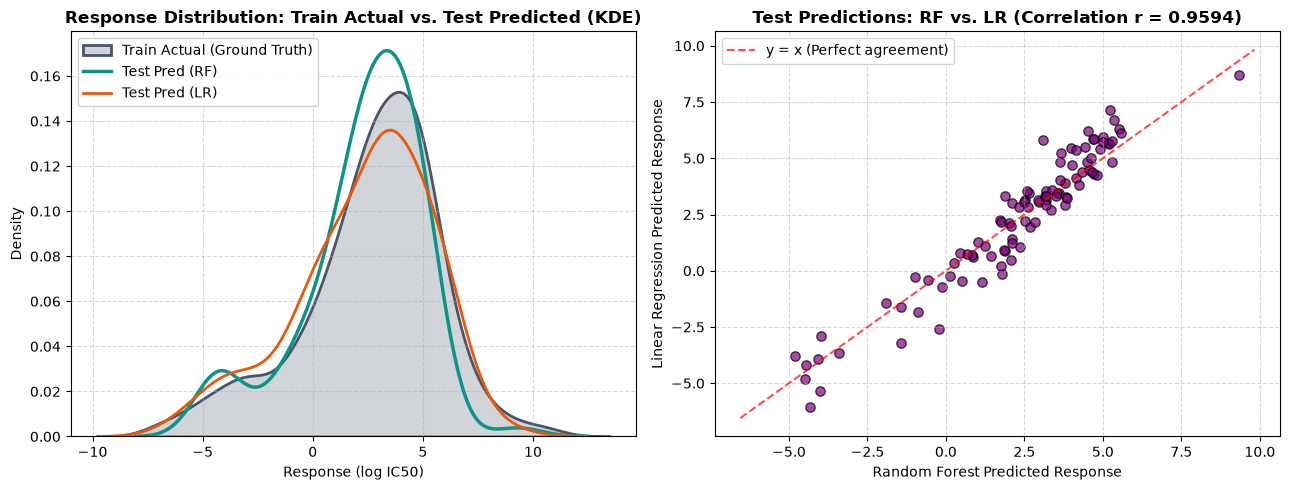

✅ 已更新 figures/fig_test_predictions.png


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from pathlib import Path

# ── 1. 讀取處理後的資料 ─────────────────────────────────────────
train_df = pd.read_csv("results/train_processed.csv")
test_df  = pd.read_csv("results/test_processed.csv")

cell_cols = [c for c in train_df.columns if c.startswith("cell_emb_")]
drug_cols = [c for c in train_df.columns if c.startswith("drug_emb_")]
feature_cols = cell_cols + drug_cols

X_train_full = train_df[feature_cols]
y_train_full = train_df["response"]
X_test = test_df[feature_cols]

# ── 2. 用全量資料訓練並預測 Test ────────────────────────────────
# (1) Random Forest (Model C)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_full, y_train_full)
preds_rf = rf.predict(X_test)

# (2) Linear Regression (Model C)
lr = LinearRegression()
lr.fit(X_train_full, y_train_full)
preds_lr = lr.predict(X_test)

# (3) Lightweight PCA + LR
pipe_pca = Pipeline([
    ("pca", PCA(n_components=20, random_state=42)),
    ("lr", LinearRegression())
])
pipe_pca.fit(X_train_full, y_train_full)
preds_pca = pipe_pca.predict(X_test)

# ── 3. 儲存預測結果表 ──────────────────────────────────────────
pred_df = test_df[["sample_id", "cell_line_id", "drug_id"]].copy()
pred_df["pred_response_rf"] = np.round(preds_rf, 4)
pred_df["pred_response_lr"] = np.round(preds_lr, 4)
pred_df["pred_response_pca_lr"] = np.round(preds_pca, 4)
pred_df["response"] = np.round(preds_rf, 4)

Path("results").mkdir(exist_ok=True)
pred_df.to_csv("results/test_predictions.csv", index=False)
print("✅ 已儲存 results/test_predictions.csv (98 筆預測值)")

# ── 4. 統計與可視化 (改用 KDE 密度曲線) ────────────────────────
Path("figures").mkdir(exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 圖 1: 分佈比較 (KDE 曲線，灰色背景清楚呈現)
sns.kdeplot(train_df["response"], ax=axes[0], fill=True, color="#4a5568", alpha=0.25, linewidth=2, label="Train Actual (Ground Truth)")
sns.kdeplot(preds_rf, ax=axes[0], color="#0d9488", linewidth=2.5, label="Test Pred (RF)")
sns.kdeplot(preds_lr, ax=axes[0], color="#ea580c", linewidth=2, label="Test Pred (LR)")
axes[0].set_title("Response Distribution: Train Actual vs. Test Predicted (KDE)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Response (log IC50)")
axes[0].set_ylabel("Density")
axes[0].legend(loc="upper left", framealpha=0.9)
axes[0].grid(True, linestyle="--", alpha=0.5)

# 圖 2: RF 與 LR 預測一致性散佈圖
corr = np.corrcoef(preds_rf, preds_lr)[0, 1]
axes[1].scatter(preds_rf, preds_lr, color="purple", alpha=0.7, edgecolors="k", s=45)
min_v = min(preds_rf.min(), preds_lr.min()) - 0.5
max_v = max(preds_rf.max(), preds_lr.max()) + 0.5
axes[1].plot([min_v, max_v], [min_v, max_v], "r--", alpha=0.7, label="y = x (Perfect agreement)")
axes[1].set_title(f"Test Predictions: RF vs. LR (Correlation r = {corr:.4f})", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Random Forest Predicted Response")
axes[1].set_ylabel("Linear Regression Predicted Response")
axes[1].legend(loc="upper left")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("figures/fig_test_predictions.png", dpi=300)
plt.show()
print("✅ 已更新 figures/fig_test_predictions.png")


## 3 model comparison

In [3]:
# ── Part 6: 測試集預測比較 (RF 100 棵 vs. RF 50 棵 vs. Linear Regression) ────────
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# 1. 讀取資料
train_df = pd.read_csv("results/train_processed.csv")
test_df  = pd.read_csv("results/test_processed.csv")

cell_cols = [c for c in train_df.columns if c.startswith("cell_emb_")]
drug_cols = [c for c in train_df.columns if c.startswith("drug_emb_")]
feature_cols = cell_cols + drug_cols

X_train = train_df[feature_cols]
y_train = train_df["response"]
X_test  = test_df[feature_cols]

# 2. 訓練三個模型
rf100 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
rf50  = RandomForestRegressor(n_estimators=50, random_state=42).fit(X_train, y_train)
lr    = LinearRegression().fit(X_train, y_train)

# 3. 預測 Test 資料
pred_rf100 = rf100.predict(X_test)
pred_rf50  = rf50.predict(X_test)
pred_lr    = lr.predict(X_test)

# 4. 統計預測值分佈
df_stats = pd.DataFrame({
    "RF (100 棵)": pred_rf100,
    "RF (50 棵)": pred_rf50,
    "Linear Regression": pred_lr
}).describe().round(3)

print("=== 測試集 (98 筆) 預測統計分佈 ===")
print(df_stats)

# 5. 計算兩兩相關性
corr_rf50_rf100 = np.corrcoef(pred_rf50, pred_rf100)[0, 1]
corr_rf50_lr    = np.corrcoef(pred_rf50, pred_lr)[0, 1]
corr_rf100_lr   = np.corrcoef(pred_rf100, pred_lr)[0, 1]

print("\n=== 預測相關係數 (Correlation) ===")
print(f"RF (50 棵) vs. RF (100 棵)   : {corr_rf50_rf100:.4f}")
print(f"RF (50 棵) vs. Linear Reg   : {corr_rf50_lr:.4f}")
print(f"RF (100 棵) vs. Linear Reg  : {corr_rf100_lr:.4f}")

# 6. 把 RF (50 棵) 也加入並存回 test_predictions.csv
pred_out = test_df[["sample_id", "cell_line_id", "drug_id"]].copy()
pred_out["pred_response_rf100"] = np.round(pred_rf100, 4)
pred_out["pred_response_rf50"]  = np.round(pred_rf50, 4)
pred_out["pred_response_lr"]    = np.round(pred_lr, 4)
pred_out["response"]            = np.round(pred_rf50, 4)  # 推薦以高性價比的 RF50 作為最終提交

pred_out.to_csv("results/test_prediction/test_predictions.csv", index=False)
print("\n✅ 已更新 results/test_prediction/test_predictions.csv")


=== 測試集 (98 筆) 預測統計分佈 ===
       RF (100 棵)  RF (50 棵)  Linear Regression
count      98.000     98.000             98.000
mean        2.291      2.279              2.340
std         2.689      2.695              3.052
min        -4.820     -4.824             -6.047
25%         1.167      1.073              0.677
50%         2.753      2.761              3.055
75%         4.143      4.199              4.452
max         9.324      9.311              8.710

=== 預測相關係數 (Correlation) ===
RF (50 棵) vs. RF (100 棵)   : 0.9983
RF (50 棵) vs. Linear Reg   : 0.9591
RF (100 棵) vs. Linear Reg  : 0.9594

✅ 已更新 results/test_prediction/test_predictions.csv


## Make Graphs

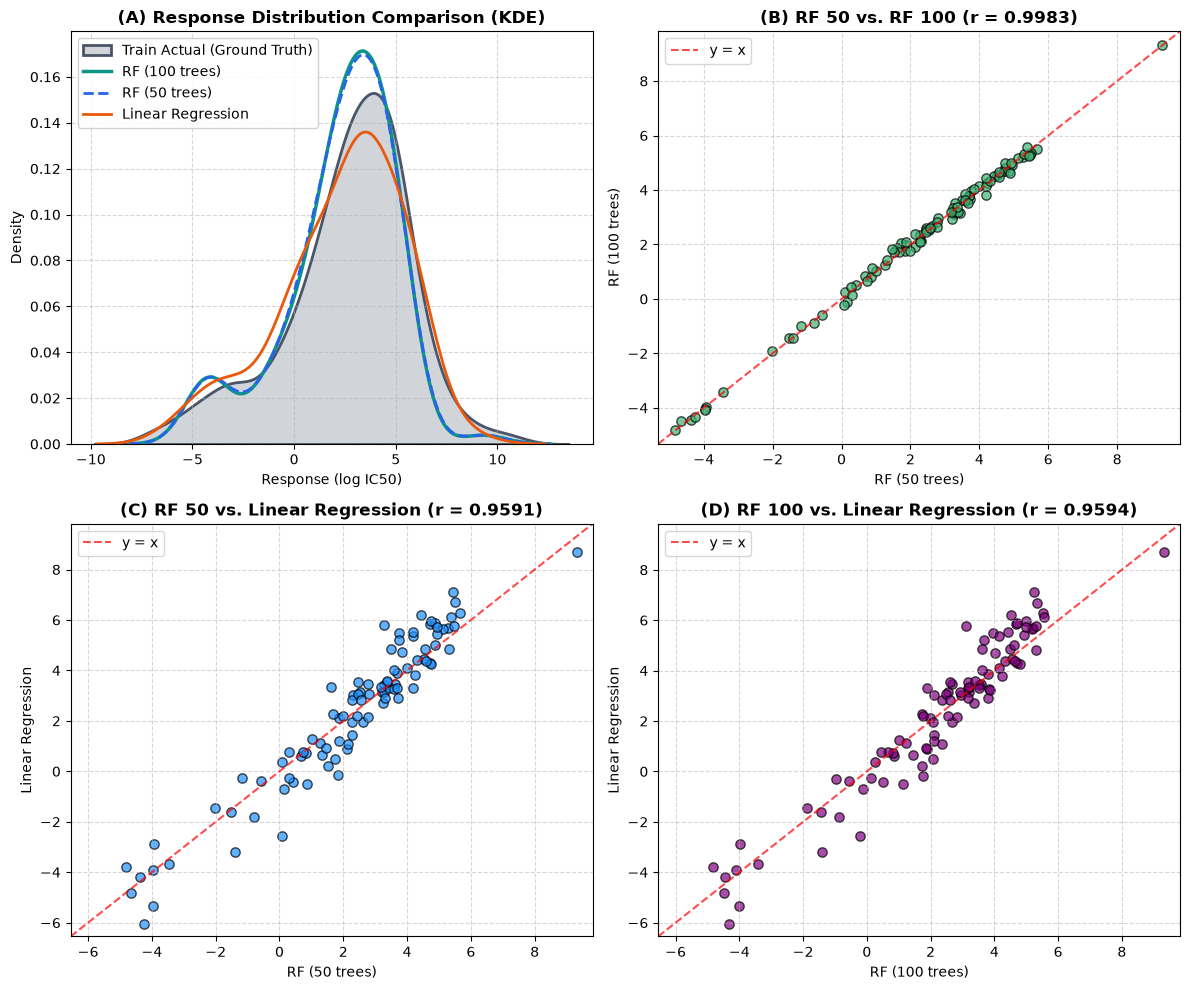

✅ 已成功重新繪製並儲存 figures/fig_test_predictions_compare.png


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

train_df = pd.read_csv("results/train_processed.csv")
test_df  = pd.read_csv("results/test_processed.csv")

feats = [c for c in train_df.columns if c.startswith("cell_emb_") or c.startswith("drug_emb_")]
X_tr, y_tr = train_df[feats], train_df["response"]
X_test = test_df[feats]

# 訓練三個模型
rf100 = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_tr, y_tr)
rf50  = RandomForestRegressor(n_estimators=50, random_state=42).fit(X_tr, y_tr)
lr    = LinearRegression().fit(X_tr, y_tr)

pred_rf100 = rf100.predict(X_test)
pred_rf50  = rf50.predict(X_test)
pred_lr    = lr.predict(X_test)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ── 圖 (A)：改用 KDE 密度曲線，灰色作為背景色塊清晰可見 ──────────────
# 1. Train 真實值：半透明灰色背景填充 + 邊框
sns.kdeplot(train_df["response"], ax=axes[0, 0], fill=True, color="#4a5568", alpha=0.25, linewidth=2, label="Train Actual (Ground Truth)")
# 2. 三個模型：清楚分明的彩色線條
sns.kdeplot(pred_rf100, ax=axes[0, 0], color="#0d9488", linewidth=2.5, label="RF (100 trees)")
sns.kdeplot(pred_rf50,  ax=axes[0, 0], color="#2563eb", linewidth=2, linestyle="--", label="RF (50 trees)")
sns.kdeplot(pred_lr,    ax=axes[0, 0], color="#ea580c", linewidth=2, label="Linear Regression")

axes[0, 0].set_title("(A) Response Distribution Comparison (KDE)", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Response (log IC50)")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend(loc="upper left", framealpha=0.9)
axes[0, 0].grid(True, linestyle="--", alpha=0.5)

# ── 散佈圖繪製輔助函式 ────────────────────────────────────────────────
def plot_scatter(ax, x, y, xlabel, ylabel, title, color):
    corr = np.corrcoef(x, y)[0, 1]
    ax.scatter(x, y, color=color, alpha=0.7, edgecolors="k", s=45)
    lims = [min(x.min(), y.min()) - 0.5, max(x.max(), y.max()) + 0.5]
    ax.plot(lims, lims, "r--", alpha=0.7, label="y = x")
    ax.set_title(f"{title} (r = {corr:.4f})", fontsize=12, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.legend(loc="upper left")
    ax.grid(True, linestyle="--", alpha=0.5)

# 圖 (B) RF 50 vs RF 100
plot_scatter(axes[0, 1], pred_rf50, pred_rf100, "RF (50 trees)", "RF (100 trees)",
             "(B) RF 50 vs. RF 100", "mediumseagreen")

# 圖 (C) RF 50 vs LR
plot_scatter(axes[1, 0], pred_rf50, pred_lr, "RF (50 trees)", "Linear Regression",
             "(C) RF 50 vs. Linear Regression", "dodgerblue")

# 圖 (D) RF 100 vs LR
plot_scatter(axes[1, 1], pred_rf100, pred_lr, "RF (100 trees)", "Linear Regression",
             "(D) RF 100 vs. Linear Regression", "purple")

plt.tight_layout()
Path("figures").mkdir(exist_ok=True)
plt.savefig("figures/fig_test_predictions_compare.png", dpi=300)
plt.show()
print("✅ 已成功重新繪製並儲存 figures/fig_test_predictions_compare.png")


## 7. Summary & Reflections

> **CMJM criterion:** "What you did, what you found, what you decided, and what you would do differently with more time."

### What I did
[Summary of the steps taken]

### Key findings
[2–4 bullet points]

### Problems I noticed
[Including any issues with the data OR with my own approach]

### If I had more time
[What additional checks or analyses you would do]